# Practice Set 15: Capstone Visualizations

**Objective:** Create three publication-quality visualizations that support your capstone project's narrative.

---

## Learning Objectives
By completing this problem set, you will:
- Select appropriate visualization types for different data and questions
- Apply ggplot2 best practices for clear, effective communication
- Create visualizations that tell a coherent story about your data
- Write captions that help readers interpret your figures

---

## Instructions

1. **Use your own capstone data** for all three visualizations
2. Each visualization should serve a **different purpose** (see requirements below)
3. All visualizations must include:
   - Clear, descriptive title
   - Labeled axes with units where appropriate
   - Legend (if applicable)
   - Clean theme (e.g., `theme_minimal()`, `theme_bw()`)
4. Write a brief caption (2-3 sentences) explaining what each visualization shows

---

## Setup
Load the required packages and your capstone data.

In [4]:
library(tidyverse)
library(scales)
library(ggthemes)

my_data <- read_csv("Cape Fur Seal Entanglements 2021 2025 with Units.csv")

glimpse(my_data)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor




Rows: 717 Columns: 18


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): DATE, COLONY, LOCATION, SEX, AGE, CATEGORY, ITEM, SEVERITY, ACTIO...
dbl   (4): Year, Month, Severity_Score, Event_Count
time  (1): TIME



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 717
Columns: 18
$ DATE           <chr> "12/13/2021", "12/3/2021", "12/3/2021", "11/22/2021", "…
$ TIME           <time> 07:27:00, 08:22:00, 07:07:00, 09:03:00, 10:02:00, 08:1…
$ COLONY         <chr> "Pelican Point", "Pelican Point", "Pelican Point", "Pel…
$ LOCATION       <chr> "Wreck", "Outside", "Lighthouse (S)", "Inside", "Jetty"…
$ SEX            <chr> "Male", "Male", "Female", "Female", "Female", "Female",…
$ AGE            <chr> "Adult", "Subadult", "Subadult", "Adult", "Juvenile", "…
$ CATEGORY       <chr> "Industrial", "Industrial", "Industrial", "Fishing", "I…
$ ITEM           <chr> "Packaging Strap", "Rope", "Packaging Strap", "Commerci…
$ SEVERITY       <chr> "Very Severe", "Severe", "Very Severe", "Slight", "Slig…
$ ACTION         <chr> "Rescue Attempt", "Sighting", "Sighting", "Sighting", "…
$ OUTCOME        <chr> "Item Removed", "-", "-", "-", "-", "-", "Item Removed"…
$ EQUIPMENT      <chr> "Net", "-", "-", "-", "-", "-", "Net", NA, NA, "-", "-"…
$ NUMBER         <

In [5]:
my_data_clean <- my_data %>%
  mutate(
    date = as.Date(DATE, format = "%m/%d/%Y"),
    year_month = as.Date(paste(Year, Month, "01", sep = "-")),

    # Set nice ordering for plots
    AGE = factor(AGE, levels = c("Juvenile", "Subadult", "Adult")),
    SEVERITY = factor(SEVERITY, levels = c("Slight", "Severe", "Very Severe")),
    CATEGORY = factor(CATEGORY)  # we'll reorder later for readability
  ) %>%
  filter(!is.na(date))





In [6]:
count(my_data_clean, CATEGORY, sort = TRUE)
count(my_data_clean, AGE, sort = TRUE)


CATEGORY,n
<fct>,<int>
Fishing,366
Industrial,279
Domestic,67
Natural,5


AGE,n
<fct>,<int>
NA,393
Adult,124
Juvenile,112
Subadult,88


---

## Visualization 1: Distribution or Composition (15 points)

**Purpose:** Show how your data is distributed or composed.

### Suggested plot types:

- **Histogram** – distribution of a continuous variable
- **Density plot** – smoothed distribution
- **Boxplot** – distribution across groups
- **Bar chart** – counts or proportions of categories
- **Pie/donut chart** – composition (use sparingly)

### Requirements:

- [x] Shows the distribution OR composition of at least one key variable
- [x] Includes appropriate title and axis labels
- [x] Uses color meaningfully \(not just decoratively\)
- [x] Caption explains what pattern or insight the reader should notice

### Questions to consider:

- What is the shape of your data's distribution? (Normal? Skewed? Bimodal?)
- Are there outliers that need explanation?
- How do distributions differ across groups?



In [7]:
viz1_df <- my_data_clean %>%
  count(CATEGORY, AGE, name = "n_events") %>%
  group_by(CATEGORY) %>%
  mutate(
    total_cat = sum(n_events),
    prop = n_events / total_cat
  ) %>%
  ungroup() %>%
  mutate(
    CATEGORY = fct_reorder(CATEGORY, total_cat, .desc = TRUE)
  )



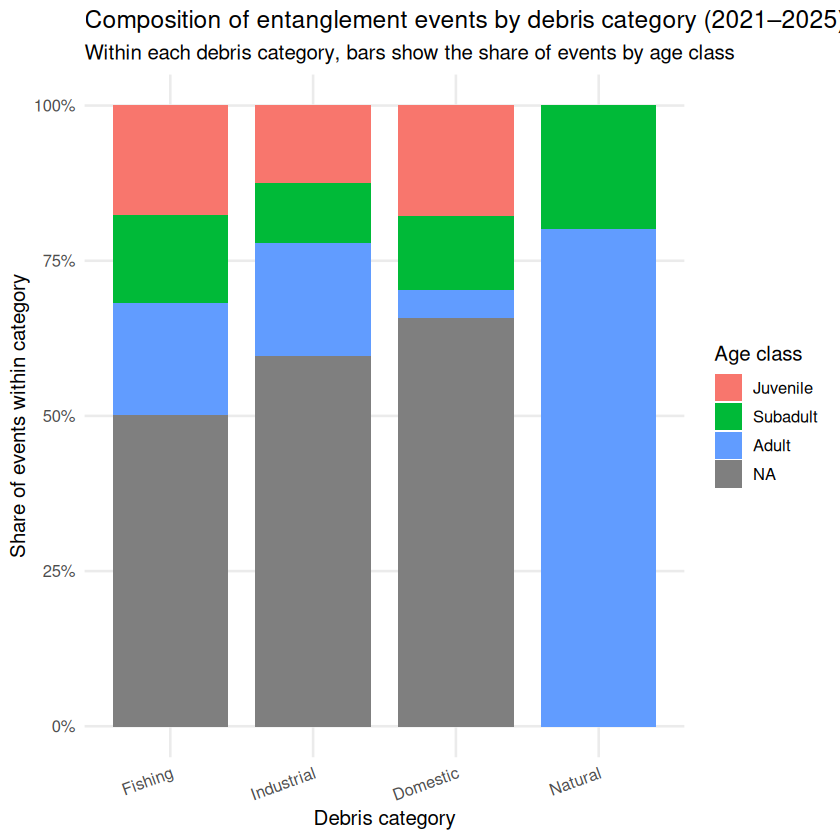

In [8]:
viz1 <- ggplot(viz1_df, aes(x = CATEGORY, y = prop, fill = AGE)) +
  geom_col(width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(
    title = "Composition of entanglement events by debris category (2021–2025)",
    subtitle = "Within each debris category, bars show the share of events by age class",
    x = "Debris category",
    y = "Share of events within category",
    fill = "Age class"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 20, hjust = 1),
    panel.grid.minor = element_blank()
  )

viz1


### Caption for Visualization 1

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 1:** This figure shows how entanglement incidents are distributed across debris categories and how age classes contribute within each category. It helps identify which debris types make up the largest portion of recorded entanglements and whether juveniles or subadults account for a higher share of cases within common debris categories, important for targeting prevention and response strategies.



---

## Visualization 2: Relationship or Comparison (15 points)

**Purpose:** Show a relationship between variables OR compare groups.

### Suggested plot types:
- **Scatterplot** – relationship between two continuous variables
- **Line plot** – trends over time or sequence
- **Grouped bar chart** – comparing categories across groups
- **Faceted plots** – same relationship across subgroups
- **Correlation heatmap** – relationships among multiple variables

### Requirements:
- [ ] Shows a relationship between at least two variables OR compares groups
- [ ] Includes appropriate title and axis labels
- [ ] Uses `geom_smooth()`, trend lines, or reference lines if appropriate
- [ ] Caption explains the relationship or comparison and its significance

### Questions to consider:
- Is the relationship positive, negative, or nonlinear?
- Are there subgroups that behave differently?
- What is the practical significance of this relationship for your capstone question?

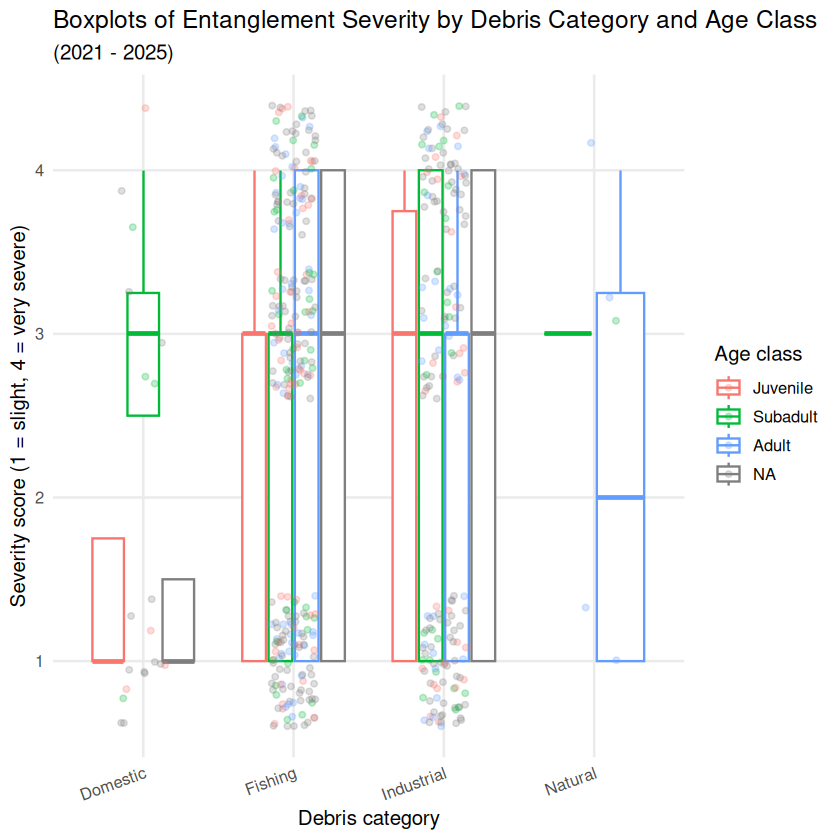

In [19]:
# VISUALIZATION 2: Relationship or Comparison

viz2 <- ggplot(
  my_data_clean %>% filter(!is.na(Severity_Score)),
  aes(x = CATEGORY, y = Severity_Score, color = AGE)
) +
  geom_boxplot(outlier.shape = NA, width = 0.7) +
  geom_jitter(width = 0.15, alpha = 0.25, size = 1.2) +
  labs(
    title = "Boxplots of Entanglement Severity by Debris Category and Age Class", 
    subtitle = "(2021 - 2025)", 
    x = "Debris category",
    y = "Severity score (1 = slight, 4 = very severe)",
    color = "Age class"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 20, hjust = 1),
    panel.grid.minor = element_blank()
  )

viz2


### Caption for Visualization 2

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 2:** This figure compares severity scores across debris categories and age classes. It highlights whether certain debris types \(e.g., industrial vs fishing\) are linked to more severe entanglements and whether juveniles/subadults tend to experience higher severity within those categories, which helps prioritize mitigation efforts.



---

## Visualization 3: Change Over Time or Space (15 points)

**Purpose:** Show how something changes across time, geography, or another ordered dimension.

### Suggested plot types:
- **Line chart** – trends over time
- **Area chart** – cumulative changes over time
- **Map** – spatial patterns (if you have geographic data)
- **Slope chart** – change between two time points
- **Faceted time series** – trends across multiple groups

### Requirements:
- [ ] Shows change across time, space, or another meaningful sequence
- [ ] Time axis is properly formatted (if applicable)
- [ ] Key events, thresholds, or reference points are annotated (if relevant)
- [ ] Caption explains the trend and its implications for your capstone

### Questions to consider:
- Is there a clear trend (increasing, decreasing, cyclical)?
- Are there notable events or breakpoints?
- How does this temporal/spatial pattern connect to your research question?

In [21]:
monthly_counts <- my_data_clean %>%
  group_by(year_month) %>%
  summarise(events = sum(Event_Count, na.rm = TRUE), .groups = "drop")


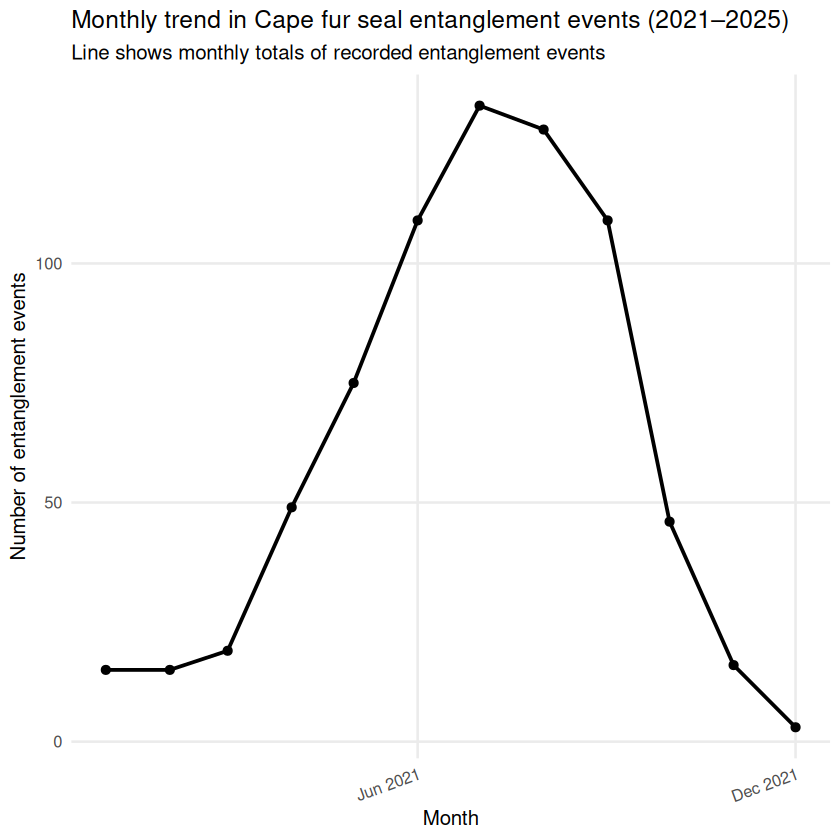

In [22]:
# VISUALIZATION 3: Change Over Time or Space

viz3 <- ggplot(monthly_counts, aes(x = year_month, y = events)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.8) +
  labs(
    title = "Monthly trend in Cape fur seal entanglement events (2021–2025)",
    subtitle = "Line shows monthly totals of recorded entanglement events",
    x = "Month",
    y = "Number of entanglement events"
  ) +
  scale_x_date(date_breaks = "6 months", date_labels = "%b %Y") +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 20, hjust = 1),
    panel.grid.minor = element_blank()
  )

viz3


### Caption for Visualization 3

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 3:** This figure shows monthly totals of Cape fur seal entanglement events from 2021 to 2025, illustrating how the frequency of incidents changes over time. The time series highlights periods of higher and lower entanglement activity, suggesting possible seasonal or operational influences. Understanding these temporal patterns helps identify when monitoring, cleanup, and intervention efforts may be most effective.



---

## Reflection Questions (5 points)

Answer the following questions in 2-4 sentences each.

### Question 1

**How do your three visualizations work together to tell a story about your capstone project?**

_The first visualization shows which debris categories and age classes make up most entanglement events, establishing the overall pattern of the problem. The second visualization compares severity across debris categories and age groups, showing which types of debris are linked to worse outcomes and for whom. The third visualization adds a time dimension by showing how entanglements change over time, helping connect the scale and severity of the problem to when interventions might be most needed._


### Question 2

**Which visualization was most challenging to create, and why?**

_The third visualization, showing change over time, was the most challenging because it required aggregating the data into monthly totals and correctly formatting the date axis. It also took extra care to make the trend clear and readable while keeping the plot clean and not cluttered with too many details._


### Question 3

**What is one thing you would improve about your visualizations if you had more time?**

_With more time, I would refine the visualizations by adding clearer annotations that highlight key findings, such as the most harmful debris type or the most affected age group. I would also explore breaking the time\-series plot down by colony or location to better show spatial differences and identify potential hotspots._


---

## Grading Rubric (50 points total)

| Component | Points | Criteria |
|-----------|--------|----------|
| Visualization 1 | 15 | Appropriate type, clear labels, meaningful use of color, insightful caption |
| Visualization 2 | 15 | Shows relationship/comparison clearly, proper formatting, informative caption |
| Visualization 3 | 15 | Shows change effectively, proper time/space formatting, relevant caption |
| Reflection | 5 | Thoughtful answers demonstrating understanding of visualization choices |

### What makes a visualization "publication quality"?
- Readable fonts and appropriate sizing
- Clear hierarchy (title > subtitle > labels > caption)
- Minimal chart junk (no unnecessary gridlines, borders, or decoration)
- Accessible colors (consider colorblind-friendly palettes)
- Self-contained (a reader can understand it without reading surrounding text)

---

## Helpful Code Snippets

### Formatting dates on x-axis
```r
scale_x_date(date_labels = "%b %Y", date_breaks = "3 months")
```

### Adding a trend line
```r
geom_smooth(method = "lm", se = FALSE, color = "red")
```

### Faceting by a variable
```r
facet_wrap(~category_variable, scales = "free_y")
```

### Colorblind-friendly palette
```r
scale_color_brewer(palette = "Set2")
scale_fill_viridis_d()
```

### Adding annotations
```r
annotate("text", x = date_value, y = y_value, label = "Event", hjust = 0)
geom_vline(xintercept = as.Date("2020-03-15"), linetype = "dashed")
```

### Saving high-resolution figures
```r
ggsave("figure1.png", viz1, width = 8, height = 6, dpi = 300)
```

---

## Submission

Submit the following:
1. This completed notebook (.ipynb file)
2. Three separate image files of your visualizations (.png, 300 dpi)

**Naming convention:** `LastName_FirstName_capstone_viz.ipynb`